In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage

In [2]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [3]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


In [4]:
def get_canny_edges_auto(grey, sigma=0.33, debug=True, title="Canny Edges (Auto)"):

    # Estimate noise level using median
    v = np.median(grey)

    # Automatic thresholds
    low  = int(max(0, (1.0 - sigma) * v))
    high = int(min(255, (1.0 + sigma) * v))

    edges = cv2.Canny(grey, low, high)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(edges, cmap="gray")
        plt.title(f"{title} (low={low}, high={high})")
        plt.axis("off")

    return edges


Loaded images/easy/29.png   shape=(318, 477, 3)
Loaded images/easy/not_that_easy.jpg   shape=(433, 612, 3)
Loaded images/easy/easy.jpg   shape=(459, 612, 3)
Loaded images/easy/20.png   shape=(630, 1200, 3)
Loaded images/medium/12.png   shape=(1080, 1920, 3)
Loaded images/medium/30.png   shape=(204, 890, 3)
Loaded images/medium/31.png   shape=(827, 1412, 3)
Loaded images/hard/21.png   shape=(733, 1100, 3)
Loaded images/hard/frame600.jpg   shape=(2160, 3840, 3)
Loaded images/hard/frame1.jpg   shape=(2160, 3840, 3)
21.png from the hard set


(np.float64(-0.5), np.float64(1099.5), np.float64(732.5), np.float64(-0.5))

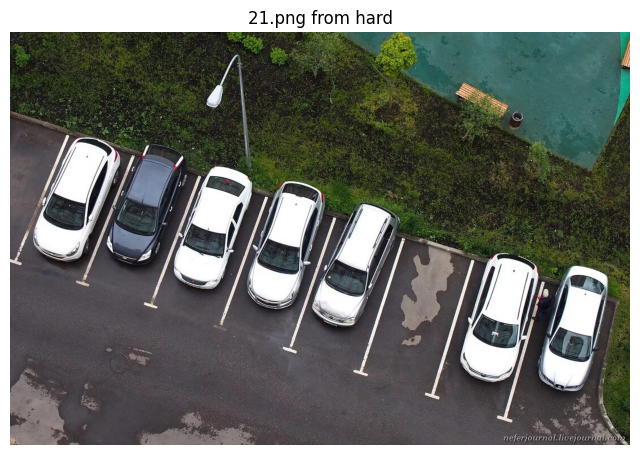

In [120]:


available_images = {
    "easy": [
        "29.png",
        "not_that_easy.jpg",
        "easy.jpg",
        "20.png",
    ],
    "medium": [
        "12.png",
        "30.png",
        "31.png",
    ],
    "hard": [
        "21.png",
        "frame600.jpg",
        "frame1.jpg",
    ]
}

loaded_images = {}

for set_name, file_list in available_images.items():
    loaded_images[set_name] = {}
    
    for fname in file_list:
        path = os.path.join("images", set_name, fname)
        img = cv2.imread(path)

        if img is None:
            print(f"⚠️ Could not load image: {path}")
        else:
            loaded_images[set_name][fname] = img
            print(f"Loaded {path}   shape={img.shape}")

# --- EASY
#(set_name, image_name) = ("easy", "29.png")
#(set_name, image_name) = ("easy", "not_that_easy.jpg")
#(set_name, image_name) = ("easy", "easy.jpg")
#(set_name, image_name) = ("easy", "20.png")

# --- MEDIUM
#(set_name, image_name) = ("medium", "12.png")
#(set_name, image_name) = ("medium", "30.png")
#(set_name, image_name) = ("medium", "31.png")

# --- HARD
#(set_name, image_name) = ("hard", "frame600.jpg")
#(set_name, image_name) = ("hard", "frame1.jpg")
(set_name, image_name) = ("hard", "21.png")

print(f"{image_name} from the {set_name} set")
img = images[set_name][image_name]
image = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"{image_name} from {set_name}")
plt.axis("off")

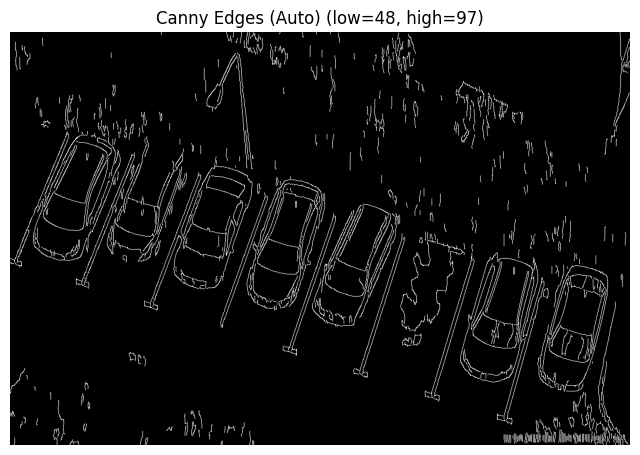

In [121]:
def step_1(img):
    img_grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(img_grey, (3,21), 0)
    canny_output = get_canny_edges_auto(blurred)

    return canny_output, img_grey

canny_output, grey = step_1(image)

In [122]:
def cluster_vertical_lines(lines, distance_thresh=20):
    """
    Takes Hough lines and merges vertical-ish lines into averaged lines.
    distance_thresh: max |rho difference| allowed in the same cluster.
    Preserves the actual slanted angle instead of forcing theta = 0.
    """
    vertical_rhos = []
    vertical_thetas = []

    # Extract vertical-ish lines
    for line in lines:
        rho, theta = line

        # Allow angles within ±20° of vertical
        if theta < np.deg2rad(50) or theta > np.deg2rad(160):
            vertical_rhos.append(rho)
            vertical_thetas.append(theta)

    if not vertical_rhos:
        return []

    # Sort by rho
    idx = np.argsort(vertical_rhos)
    rhos_sorted = np.array(vertical_rhos)[idx]
    thetas_sorted = np.array(vertical_thetas)[idx]

    clusters = []
    current_rhos = [rhos_sorted[0]]
    current_thetas = [thetas_sorted[0]]

    for r, t in zip(rhos_sorted[1:], thetas_sorted[1:]):
        if abs(r - current_rhos[-1]) < distance_thresh:
            current_rhos.append(r)
            current_thetas.append(t)
        else:
            clusters.append((current_rhos, current_thetas))
            current_rhos = [r]
            current_thetas = [t]

    clusters.append((current_rhos, current_thetas))

    # Average lines in each cluster
    merged = []
    for rhos, thetas in clusters:
        avg_rho = np.mean(rhos)

        # Normalise angles first so they average correctly
        thetas_norm = [normalise_angle(t) for t in thetas]
        avg_theta_norm = np.mean(thetas_norm)

        # Convert back to full range (0 to pi)
        if avg_theta_norm < 0:
            avg_theta = avg_theta_norm + np.pi
        else:
            avg_theta = avg_theta_norm

        merged.append((avg_rho, avg_theta))

    return merged

In [123]:
def normalise_angle(theta):
    # Convert to orientation angle (0–π) but symmetric
    return theta if theta < np.pi/2 else theta - np.pi

In [124]:
def modal_angle(angles, bin_size_deg=2):
    if len(angles) == 0:
        return None

    bin_size = np.deg2rad(bin_size_deg)
    bins = np.arange(-np.pi/2, np.pi/2 + bin_size, bin_size)

    hist, edges = np.histogram(angles, bins=bins)
    idx = np.argmax(hist)

    # modal angle = center of bin
    modal = (edges[idx] + edges[idx + 1]) / 2
    return modal


In [125]:
def filter_by_modal_angle(lines, angle_tolerance_deg=5):
    """
    lines: list of (rho, theta, x1, y1, x2, y2)
    returns only the segments whose angle matches the modal angle
    """

    if not lines:
        return []

    # Extract normalized angles
    angs = [normalise_angle(theta) for (rho, theta, *_rest) in lines]

    # Find modal orientation
    modal = modal_angle(angs)
    if modal is None:
        return []

    tol = np.deg2rad(angle_tolerance_deg)

    filtered = []
    for (rho, theta, x1, y1, x2, y2) in lines:
        ang = normalise_angle(theta)
        if abs(ang - modal) < tol:
            filtered.append((rho, theta, x1, y1, x2, y2))

    return filtered, modal


In [126]:
def line_to_rho_theta(x1, y1, x2, y2):
    angle = np.arctan2((y2 - y1), (x2 - x1))
    theta = angle + np.pi/2

    # midpoint of the segment
    x0 = (x1 + x2) / 2
    y0 = (y1 + y2) / 2

    rho = x0 * np.cos(theta) + y0 * np.sin(theta)

    return rho, theta


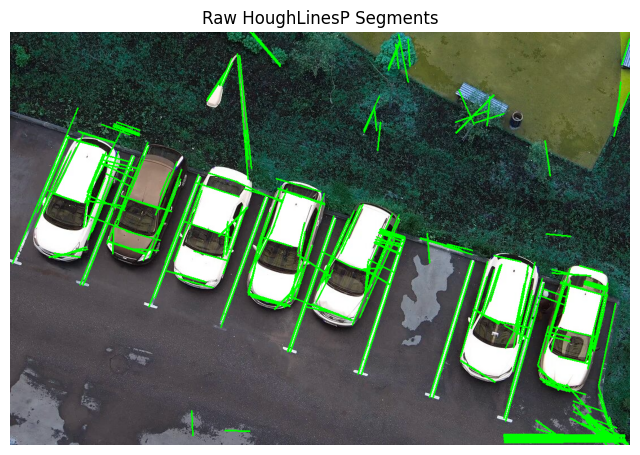

In [127]:
def step_2(canny_input, image, downsample=False, scale=0.5):
    # Copy image for drawing
    if downsample:
        image = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        canny_input = cv2.resize(canny_input, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    # Hough transform (probabilistic)
    linesP = cv2.HoughLinesP(
        canny_input,
        rho=1,
        theta=np.pi/180,
        threshold=50,
        minLineLength=40,
        maxLineGap=15
    )
    
    # Copy image for drawing
    houghP_vis = image.copy()
    
    # Draw detected segments
    if linesP is not None:
        for (x1, y1, x2, y2) in linesP[:,0]:
            cv2.line(houghP_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(houghP_vis)
    plt.title("Raw HoughLinesP Segments")
    plt.axis("off")

    return linesP

linesP = step_2(canny_output, image)



Modal Angle: 0.4014257279586986


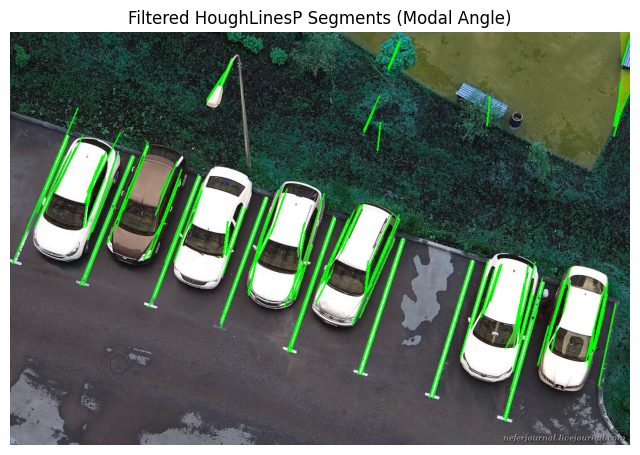

In [131]:
def step_3(linesP, image):
    
    hough_lines = image.copy()
    
    horiz_center = np.pi / 2
    horiz_thresh = np.deg2rad(45)
    
    non_horiz = []
    
    if linesP is not None:
        for (x1, y1, x2, y2) in linesP[:,0]:
            rho, theta = line_to_rho_theta(x1, y1, x2, y2)
    
            # apply same horizontal filtering
            if abs(theta - horiz_center) >= horiz_thresh:
                # store full segment
                non_horiz.append((rho, theta, x1, y1, x2, y2))
    
    # Filter by modal angle (but keep original segments)
    filtered_lines, modal_angle_of_image = filter_by_modal_angle(non_horiz, angle_tolerance_deg=20)
    
    # Draw filtered segments (NOT infinite lines)
    hough_lines = image.copy()
    
    for (rho, theta, x1, y1, x2, y2) in filtered_lines:
        cv2.line(hough_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(hough_lines)
    plt.title("Filtered HoughLinesP Segments (Modal Angle)")
    plt.axis("off")

    return filtered_lines, modal_angle_of_image

filtered_lines, modal_angle_of_image = step_3(linesP, image)
print(f"Modal Angle: {modal_angle_of_image}")

23.00000000000016


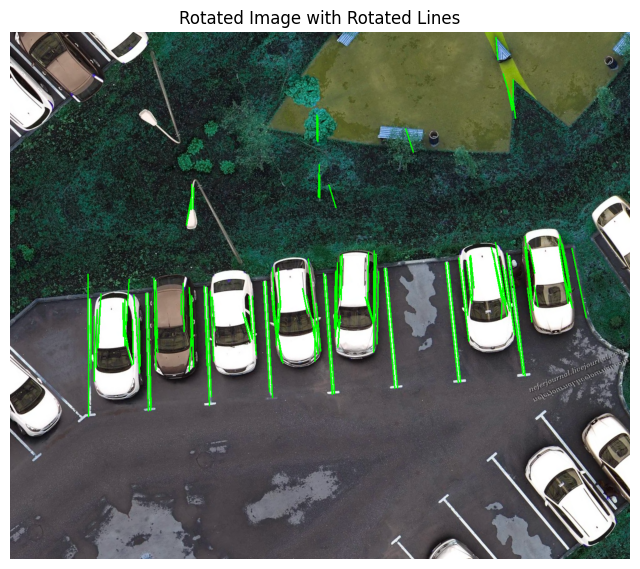

In [137]:
def rotate_image_nocrop(image, angle_deg, threshold_deg=10):
    """
    Rotate an image around its center without cropping.
    If |angle| < threshold_deg, no rotation is applied.
    Returns (rotated_image, affine_matrix M).
    """
    # Skip rotation if angle is small
    if abs(angle_deg) < threshold_deg:
        M = None
        return image.copy(), M

    (h, w) = image.shape[:2]
    center = (w / 2, h / 2)

    # Rotation matrix
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    # Compute new bounding box
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])

    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)

    # Adjust translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    # Rotate with reflection padding
    rotated = cv2.warpAffine(
        image, M, (new_w, new_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    return rotated, M

def rotate_points(segments, M):
    """
    Rotate a list of line segments using affine matrix M.
    segments = [(x1,y1,x2,y2), ...]
    Works even if M is the identity matrix (no rotation).
    """
    rotated = []
    if M is None:
        return segments
        
    for (x1, y1, x2, y2) in segments:
        p1 = M @ np.array([x1, y1, 1.0])
        p2 = M @ np.array([x2, y2, 1.0])

        rotated.append((
            int(round(p1[0])),
            int(round(p1[1])),
            int(round(p2[0])),
            int(round(p2[1]))
        ))

    return rotated

def recompute_rho_theta_for_rotated_segments(rotated_segments):
    updated = []
    for (x1, y1, x2, y2) in rotated_segments:
        rho, theta = line_to_rho_theta(x1, y1, x2, y2)
        updated.append((rho, theta, x1, y1, x2, y2))
    return updated

rotation_angle_deg = np.rad2deg(modal_angle_of_image)
print(rotation_angle_deg)
rotated_image, M = rotate_image_nocrop(image, rotation_angle_deg, threshold_deg=10)

segments = [(x1,y1,x2,y2) for (_,_,x1,y1,x2,y2) in filtered_lines]
rotated_segments = rotate_points(segments, M)

rotated_lines = []
for (x1, y1, x2, y2) in rotated_segments:
    new_rho, new_theta = line_to_rho_theta(x1, y1, x2, y2)
    rotated_lines.append((new_rho, new_theta, x1, y1, x2, y2))


# Make a drawable copy
output = rotated_image.copy()

# Draw each rotated segment
for (_, _, x1, y1, x2, y2) in rotated_lines:
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Show it
plt.figure(figsize=(8, 8))
plt.imshow(output)
plt.title("Rotated Image with Rotated Lines")
plt.axis("off")
plt.show()

In [129]:
def merge_by_midpoint(segments, merge_radius=50):
    """
    Merge Hough lines purely by midpoint proximity.
    segments: [(rho, theta, x1, y1, x2, y2), ...]
    merge_radius: max distance between midpoints to consider them the same group
    """

    # Compute midpoints
    mids = []
    for (rho, theta, x1, y1, x2, y2) in segments:
        mx = (x1 + x2) * 0.5
        my = (y1 + y2) * 0.5
        mids.append((mx, my, x1, y1, x2, y2))

    # Clusters = list of lists
    clusters = []

    for item in mids:
        mx, my, x1, y1, x2, y2 = item
        placed = False

        # Check each existing cluster
        for c in clusters:
            # distance to cluster center (mean midpoint)
            cx = c['cx']
            cy = c['cy']
            if np.hypot(mx - cx, my - cy) < merge_radius:
                c['items'].append(item)
                # update cluster center
                xs = [i[0] for i in c['items']]
                ys = [i[1] for i in c['items']]
                c['cx'] = np.mean(xs)
                c['cy'] = np.mean(ys)
                placed = True
                break

        if not placed:
            clusters.append({
                'items': [item],
                'cx': mx,
                'cy': my
            })

    # Now merge each cluster into ONE line segment
    merged = []
    for c in clusters:
        xs = []
        ys = []
        for (_,_, x1,y1,x2,y2) in c['items']:
            xs += [x1, x2]
            ys += [y1, y2]

        # Take the two furthest-apart points in the cluster
        pts = np.column_stack([xs, ys])
        if len(pts) < 2:
            continue

        # find the longest pair
        dmax = 0
        p1, p2 = pts[0], pts[0]
        for i in range(len(pts)):
            for j in range(i+1, len(pts)):
                d = np.hypot(pts[i,0]-pts[j,0], pts[i,1]-pts[j,1])
                if d > dmax:
                    dmax = d
                    p1, p2 = pts[i], pts[j]

        merged.append((int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])))

    return merged

    

(np.float64(-0.5), np.float64(1099.5), np.float64(732.5), np.float64(-0.5))

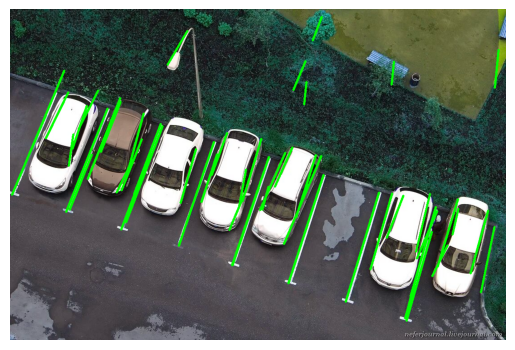

In [130]:
merged = merge_by_midpoint(filtered_lines, merge_radius=30)
filtered_by_size = []
for x1, y1, x2, y2 in merged:
    length = np.hypot(x2 - x1, y2 - y1)
    if length >= 50:
        filtered_by_size.append((x1, y1, x2, y2))

out = image.copy()
for (x1, y1, x2, y2) in filtered_by_size:
    cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 4)

plt.imshow(out)
plt.axis("off")


In [118]:
import numpy as np

def find_modal_spacing_from_longest_cluster(
    segments, 
    modal_theta,
    cluster_radius=80,
    bin_size=5,
    min_spacing=30
):
    """
    segments: list of (x1, y1, x2, y2)
    modal_theta: angle (radians) to project midpoints
    cluster_radius: grouping threshold for midpoint projections
    bin_size: histogram bucket width
    min_spacing: discard spacings smaller than this
    """

    if len(segments) < 2:
        print("Not enough segments.")
        return None, []

    # Direction vector along modal_theta
    dx = np.cos(modal_theta)
    dy = np.sin(modal_theta)

    # 1. Compute (length, projected midpoint, midpoint coords)
    items = []
    for (x1, y1, x2, y2) in segments:
        length = np.hypot(x2 - x1, y2 - y1)
        mx = (x1 + x2) * 0.5
        my = (y1 + y2) * 0.5
        s = mx * dx + my * dy  # projection along modal direction
        items.append((length, s, mx, my))

    # 2. Sort longest first
    items.sort(key=lambda x: -x[0])

    # 3. Build clusters in 1D projection space
    clusters = []
    for length, s, mx, my in items:
        placed = False
        for c in clusters:
            if abs(s - c["center_s"]) < cluster_radius:
                c["items"].append((length, s, mx, my))
                c["center_s"] = np.mean([itm[1] for itm in c["items"]])
                placed = True
                break

        if not placed:
            clusters.append({"items": [(length, s, mx, my)], "center_s": s})

    # 4. Largest cluster = real family of lines
    largest_cluster = max(clusters, key=lambda c: len(c["items"]))
    cluster_items = sorted(largest_cluster["items"], key=lambda x: x[1])

    # ===== NEW: Compute modal length =====
    lengths = [itm[0] for itm in cluster_items]
    if len(lengths) >= 2:
        lengths_arr = np.array(lengths)
        max_len = np.max(lengths_arr)
        len_bins = np.arange(0, max_len + bin_size, bin_size)
        len_hist, len_edges = np.histogram(lengths_arr, bins=len_bins)
        modal_len_idx = np.argmax(len_hist)
        modal_length = 0.5 * (len_edges[modal_len_idx] + len_edges[modal_len_idx + 1])

        print(f"Modal line length: {modal_length:.2f} pixels")
    else:
        modal_length = None
        print("Not enough lines to compute modal length.")

    # 5. Compute adjacent spacings along modal direction
    s_vals = [s for (_, s, _, _) in cluster_items]
    spacings = [abs(s_vals[i] - s_vals[i - 1]) for i in range(1, len(s_vals))]
    spacings = [d for d in spacings if d >= min_spacing]

    if len(spacings) == 0:
        print("No spacings found above min_spacing threshold.")
        return None, cluster_items

    # 6. Modal spacing via histogram
    spacings = np.array(spacings)
    max_spacing = np.max(spacings)
    bins = np.arange(0, max_spacing + bin_size, bin_size)

    hist, edges = np.histogram(spacings, bins=bins)
    modal_idx = np.argmax(hist)
    modal_spacing = 0.5 * (edges[modal_idx] + edges[modal_idx + 1])

    return modal_spacing, cluster_items


In [119]:
spacing, cluster_items = find_modal_spacing_from_longest_cluster(
    merged,
    modal_angle_of_image,
    cluster_radius=80,   # tunes how close midpoints must be to form a group
    bin_size=5
)

print("Modal spacing:", spacing)
print("Cluster size:", len(cluster_items))


Modal line length: 57.50 pixels
Modal spacing: 32.5
Cluster size: 21


In [19]:
# Function to do the pipeline on the whole image.
def do_pipeline(images_array, set_name, image_name):

    # grab the image from the array.    
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    
    
    # angle = fast_dominant_line_angle(img_grey, name="Greyscale Skeleton Test")
    # rotated, M, Minv, valid_mask = rotate_image_with_reflect(img_grey, angle)
    #
    # plt.figure(figsize=(8,8))
    # plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    # plt.title("Rotated")
    # plt.axis("off")
    blurred = cv2.GaussianBlur(img_grey, (5,5), 0)
    # # --- Directional Morphology (Opening) ---
    horiz_lines = directional_open(
        blurred, horizon=True, ksize=40, name="Horizontal Opening"
    )

    vert_lines = directional_open(
        blurred, horizon=False, ksize=50, name="Vertical Opening"
    )

    canny_output_vert = get_canny_edges_auto(vert_lines)
    # --- Top-Hat Enhancement ---
    vertical_tophat = do_tophat(
        vert_lines, (40, 1), name="Vertical Tophat Test"
    )
    horizon_tophat = do_tophat(
        horiz_lines, (3, 40), name="Horizontal Tophat Test"
    )

    # --- Clean Top-Hat Output ---
    horizon_clean = clean_tophat(
        horizon_tophat, False, name="Tophat Horizon Cleaned"
    )
    vertical_clean = clean_tophat(
        vertical_tophat, True, name="Tophat Vertical Cleaned"
    )
    binarised = binarise(vertical_clean)
    subtract_canny_from_binarised(canny_output, binarised)
    
    horizon_lines = lsd_detect_and_show(horizon_clean, debug=True)
    vertical_lines = lsd_detect_and_show(vertical_clean, debug=True)

    print("Before filtering:", len(vertical_lines))
    filtered_lines = filter_bottom_quarter_by_length(vertical_lines)
    print("After filtering:", len(filtered_lines))

    
    # plt.figure(figsize=(8, 8))
    # plt.imshow(vis)
    # plt.title("LSD Filtered")
    # plt.axis("off")
    # plt.show()
    
    return

In [20]:
# --- EASY

#do_pipeline(images, "easy", "29.png")
#do_pipeline(images, "easy", "not_that_easy.jpg")
#do_pipeline(images, "easy", "easy.jpg")
do_pipeline(images, "easy", "20.png")

# --- Medium 
#do_pipeline(images, "medium", "12.png")
#do_pipeline(images, "medium", "30.png") # Slanted
#do_pipeline(images, "medium", "31.png")

# -- Hard
#do_pipeline(images, "hard", "frame600.jpg")
#do_pipeline(images, "hard", "frame1.jpg")
#do_pipeline(images, "hard", "21.png")

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'
